In [1]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import discretize
from discretize import TensorMesh

from discretize.utils import mkvc, active_from_xyz
from simpeg.utils import plot2Ddata, model_builder
from simpeg import maps

write_output = False

import torch

In [2]:
# 1) Modelo (Δσ)
# El NPY trae contraste de conductividad Δσ en S/m 

# Frecuencias en las que se va a hacer el modelado
frequency_list = np.logspace(-4, 2, 3)

# Carga de la malla usada para el modelo 3D de conductividad 
mesh = discretize.utils.load_mesh("../../../../models/Toy6/mesh_Toy6_MT.json")

# Carga del modelo 3D de conductividad
sigma = np.load("../../../../models/Toy6/model_Toy6_MT.npy", allow_pickle=True)

# Modelo de conductividad 
sigBG = np.ones(mesh.nC) * 2e-3
air_cells = np.isclose(sigma, 1e-8)
sigBG[air_cells] = 1e-8

# Ubicación del receptor para el modelado
rx_loc = np.array([
    [0.0, 0.0, -53.7],
])

print("mesh =", mesh)
print("mesh.nC=", mesh.nC)
print("mesh.nEx=", mesh.nEx)
print("mesh.nEy=", mesh.nEy)
print("mesh.nEz=", mesh.nEz)
print("frequency_list =", frequency_list)
print("rx_loc =", rx_loc)

mesh = 
  TensorMesh: 27,000 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     30     -7,850.00      7,850.00    250.00  1,800.00    7.20
   y     30     -7,850.00      7,850.00    250.00  1,800.00    7.20
   z     30     -9,000.00      5,000.00    200.00  1,000.00    5.00


mesh.nC= 27000
mesh.nEx= 28830
mesh.nEy= 28830
mesh.nEz= 28830
frequency_list = [1.e-04 1.e-01 1.e+02]
rx_loc = [[  0.    0.  -53.7]]


In [3]:
mesh

TensorMesh: 27,000 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     30     -7,850.00      7,850.00    250.00  1,800.00    7.20
   y     30     -7,850.00      7,850.00    250.00  1,800.00    7.20
   z     30     -9,000.00      5,000.00    200.00  1,000.00    5.00

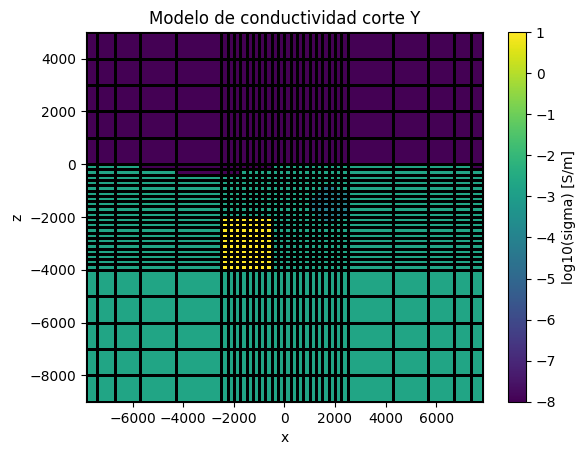

In [4]:
# 2) Plot del modelo de conductividad 3D
collect_obj = mesh.plot_slice(np.log10(sigma), grid=True, normal="Y")[0]
plt.colorbar(collect_obj, label="log10(sigma) [S/m]")
plt.title("Modelo de conductividad corte Y")
plt.savefig(f"Modelo_3D_conductividad.png", dpi=300)
plt.show()

In [5]:
# 3) Lista de receptores: impedancia compleja y tipper complejo
from simpeg.electromagnetics import natural_source as NSEM
receiver_list = []

for rx_orientation in ["xx", "xy", "yx", "yy"]:
    receiver_list.append(
        NSEM.Rx.Impedance(rx_loc, orientation=rx_orientation, component="real")
    )
    receiver_list.append(
        NSEM.Rx.Impedance(rx_loc, orientation=rx_orientation, component="imag")
    )

for rx_orientation in ["zx", "zy"]:
    receiver_list.append(
        NSEM.Rx.Tipper(rx_loc, orientation=rx_orientation, component="real")
    )
    receiver_list.append(
        NSEM.Rx.Tipper(rx_loc, orientation=rx_orientation, component="imag")
    )

source_list = [
    NSEM.Src.PlanewaveXYPrimary(receiver_list, freq)
    for freq in frequency_list
]

survey = NSEM.Survey(source_list)

print("Número de fuentes:", len(source_list))
print("Número de receptores por fuente:", len(receiver_list))

Número de fuentes: 3
Número de receptores por fuente: 12


In [6]:
# 4) Forward

problem = NSEM.Simulation3DPrimarySecondary(
    mesh=mesh,
    survey=survey,
    sigma=sigma,
    sigmaPrimary=sigBG,
    forward_only=True,
)

dobs = problem.dpred()
data = NSEM.Data(survey=survey, dobs=dobs)
#data.relative_error = 0.1
#data.noise_floor = 0.0

print("Estaciones físicas:", rx_loc.shape[0])
print("Tipos de medición definidos:", len(receiver_list))
print("Frecuencias:", len(source_list))
print("Datos totales esperados:", rx_loc.shape[0] * len(receiver_list) * len(source_list))

/home/sebas-al/miniconda3/envs/inversionprofsergio_torch/lib/python3.11/site-packages/simpeg/simulation.py:197: DefaultSolverWarning: Using the default solver: Pardiso. 

If you would like to suppress this notification, add 
warnings.filterwarnings('ignore', simpeg.utils.solver_utils.DefaultSolverWarning)
 to your script.
  return get_default_solver(warn=True)


Estaciones físicas: 1
Tipos de medición definidos: 12
Frecuencias: 3
Datos totales esperados: 36


In [7]:
#si esto ya se ejecuto no se debe volver a ejecutar para no volver a generar los archivos npy
# 5) Exportación de la respuesta calculada
n_rec = rx_loc.shape[0]
n_freq = len(frequency_list)

impedance_simpeg = np.zeros((n_rec, n_freq, 2, 2), dtype=complex)
tipper_simpeg = np.zeros((n_rec, n_freq, 2), dtype=complex)

for ifreq, src in enumerate(survey.source_list):
    # leer por receptor en el mismo survey
    zxx_r = np.asarray(data[src, receiver_list[0]])
    zxx_i = np.asarray(data[src, receiver_list[1]])

    zxy_r = np.asarray(data[src, receiver_list[2]])
    zxy_i = np.asarray(data[src, receiver_list[3]])

    zyx_r = np.asarray(data[src, receiver_list[4]])
    zyx_i = np.asarray(data[src, receiver_list[5]])

    zyy_r = np.asarray(data[src, receiver_list[6]])
    zyy_i = np.asarray(data[src, receiver_list[7]])

    tzx_r = np.asarray(data[src, receiver_list[8]])
    tzx_i = np.asarray(data[src, receiver_list[9]])

    tzy_r = np.asarray(data[src, receiver_list[10]])
    tzy_i = np.asarray(data[src, receiver_list[11]])

    impedance_simpeg[:, ifreq, 0, 0] = zxx_r + 1j * zxx_i
    impedance_simpeg[:, ifreq, 0, 1] = zxy_r + 1j * zxy_i
    impedance_simpeg[:, ifreq, 1, 0] = zyx_r + 1j * zyx_i
    impedance_simpeg[:, ifreq, 1, 1] = zyy_r + 1j * zyy_i

    tipper_simpeg[:, ifreq, 0] = tzx_r + 1j*tzx_i
    tipper_simpeg[:, ifreq, 1] = tzy_r + 1j*tzy_i

# Guardar en archivos .npy la impedancia y el tipper
np.save("impedance_SimPEG_Toy6.npy", impedance_simpeg)#Construcción del tensor Z
np.save("tipper_SimPEG_Toy6.npy", tipper_simpeg)#Construcción del tensor T

In [8]:
plot_location = rx_loc[0, :2]
print("plot_location=",plot_location)

plot_location= [0. 0.]


/tmp/ipykernel_1322234/2196681530.py:11: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.invert_xaxis()
/tmp/ipykernel_1322234/2196681530.py:11: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.invert_xaxis()


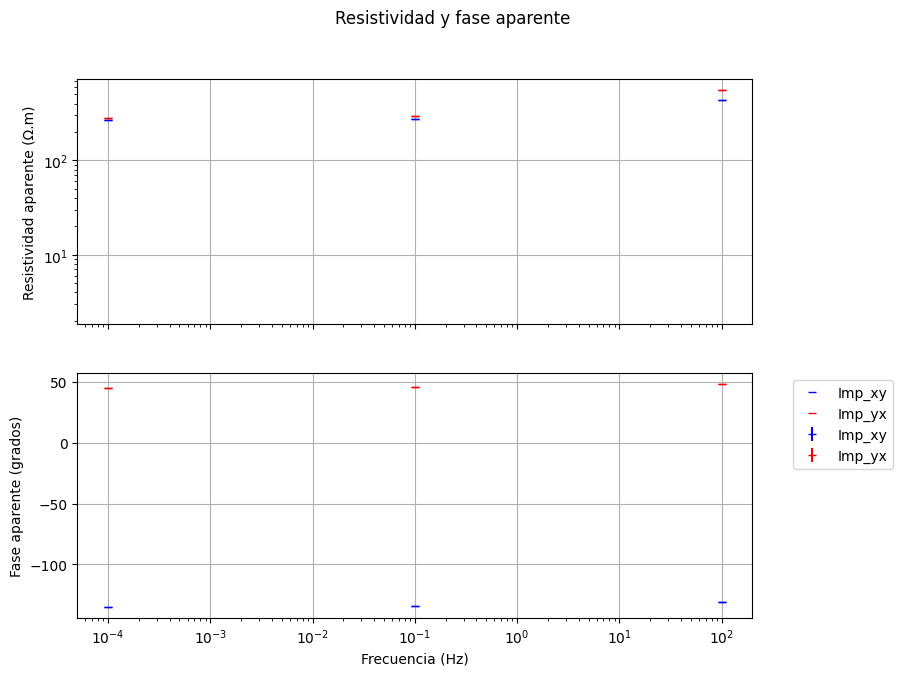

In [9]:
# 5) Plot 

# Plot de resistividad aparente y fase calculada con SimPEG
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
plt.subplots_adjust(right=0.8)

irec = 0

ax_r, ax_p = axes
for ax in axes:
    ax.invert_xaxis()
    ax.set_xscale("log")
    ax.grid(True)

ax_r.set_yscale("log")
ax_r.set_ylabel("Resistividad aparente (Ω.m)")
ax_p.set_ylabel("Fase aparente (grados)")
ax_p.set_xlabel("Frecuencia (Hz)")

ax_r = data.plot_app_res(
    plot_location,
    components=["xy", "yx"],
    ax=ax_r,
    errorbars=True,
)

ax_p = data.plot_app_phs(
    plot_location,
    components=["xy", "yx"],
    ax=ax_p,
    errorbars=True,
)

ax_p.legend(bbox_to_anchor=(1.05, 1), loc=2)
fig.suptitle(f"Resistividad y fase aparente")
plt.show()

/tmp/ipykernel_1322234/923321069.py:8: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.invert_xaxis()
/tmp/ipykernel_1322234/923321069.py:8: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.invert_xaxis()


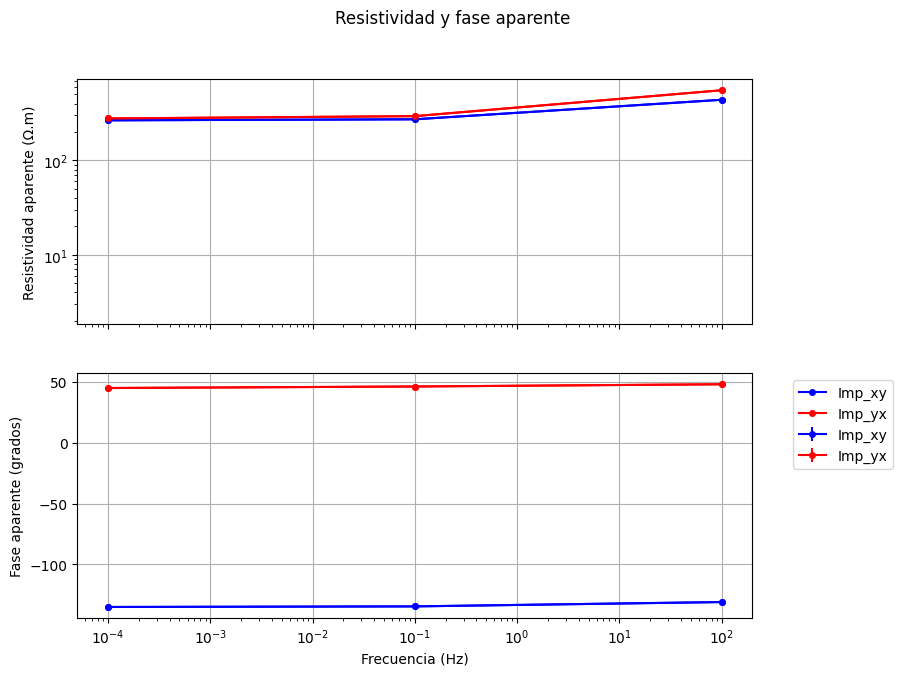

In [10]:
# Plot de resistividad aparente y fase calculada con SimPEG
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
plt.subplots_adjust(right=0.8)

ax_r, ax_p = axes

for ax in axes:
    ax.invert_xaxis()
    ax.set_xscale("log")
    ax.grid(True)

ax_r.set_yscale("log")
ax_r.set_ylabel("Resistividad aparente (Ω.m)")
ax_p.set_ylabel("Fase aparente (grados)")
ax_p.set_xlabel("Frecuencia (Hz)")

# Resistividad aparente
ax_r = data.plot_app_res(
    plot_location,
    components=["xy", "yx"],
    ax=ax_r,
    errorbars=True,
)

# Fase aparente
ax_p = data.plot_app_phs(
    plot_location,
    components=["xy", "yx"],
    ax=ax_p,
    errorbars=True,
)

# Cambiar puntos por curvas continuas
for linea in ax_r.lines:
    linea.set_linestyle("-")
    linea.set_linewidth(1.5)
    linea.set_marker("o")
    linea.set_markersize(4)

for linea in ax_p.lines:
    linea.set_linestyle("-")
    linea.set_linewidth(1.5)
    linea.set_marker("o")
    linea.set_markersize(4)

ax_p.legend(bbox_to_anchor=(1.05, 1), loc=2)

fig.suptitle("Resistividad y fase aparente")
plt.show()

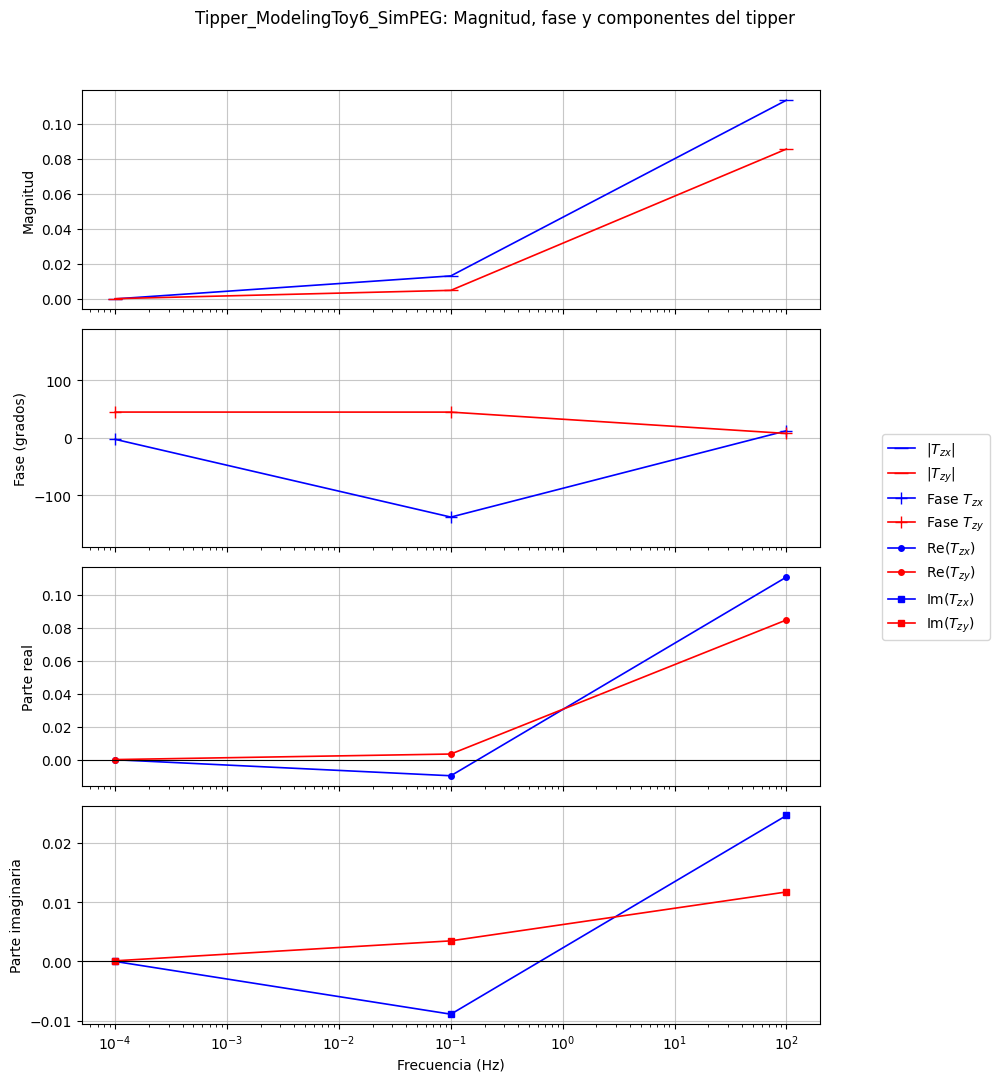

In [11]:
# Magnitud, fase, parte real e imaginaria del tipper calculada con SimPEG

Tzx_list = []
Tzy_list = []
frec = []

for src in survey.source_list:

    # Frecuencia asociada a cada fuente
    frec.append(src.frequency)

    # Componentes real e imaginaria
    tzx_r = np.atleast_1d(np.asarray(data[src, receiver_list[8]]))
    tzx_i = np.atleast_1d(np.asarray(data[src, receiver_list[9]]))

    tzy_r = np.atleast_1d(np.asarray(data[src, receiver_list[10]]))
    tzy_i = np.atleast_1d(np.asarray(data[src, receiver_list[11]]))

    # Construcción compleja del tipper
    Tzx_list.append(tzx_r + 1j * tzx_i)
    Tzy_list.append(tzy_r + 1j * tzy_i)

# (n_frecuencias, n_receptores)
Tzx = np.asarray(Tzx_list)
Tzy = np.asarray(Tzy_list)
frec = np.asarray(frec)

orden = np.argsort(frec)

frec = frec[orden]
Tzx = Tzx[orden, :]
Tzy = Tzy[orden, :]

# Magnitud, fase, real e imaginaria

Tmzx = np.abs(Tzx)
Tmzy = np.abs(Tzy)

Tpzx = np.degrees(np.angle(Tzx))
Tpzy = np.degrees(np.angle(Tzy))

Tzx_real = np.real(Tzx)
Tzx_imag = np.imag(Tzx)

Tzy_real = np.real(Tzy)
Tzy_imag = np.imag(Tzy)

# Receptor a graficar
irec = 0

c_tzx = "blue"
c_tzy = "red"

fig, (ax_mag, ax_phi, ax_real, ax_imag) = plt.subplots(
    4,
    1,
    figsize=(10, 11),
    sharex=True
)

# Magnitud
ax_mag.plot(
    frec,
    Tmzx[:, irec],
    marker="_",
    linestyle="-",
    linewidth=1.2,
    color=c_tzx,
    markersize=10,
    label=r"$|T_{zx}|$"
)

ax_mag.plot(
    frec,
    Tmzy[:, irec],
    marker="_",
    linestyle="-",
    linewidth=1.2,
    color=c_tzy,
    markersize=10,
    label=r"$|T_{zy}|$"
)

ax_mag.set_xscale("log")
ax_mag.set_ylabel("Magnitud")
ax_mag.grid(True, which="major", alpha=0.7)

# Fase
ax_phi.plot(
    frec,
    Tpzx[:, irec],
    marker="+",
    linestyle="-",
    linewidth=1.2,
    color=c_tzx,
    markersize=8,
    label=r"Fase $T_{zx}$"
)

ax_phi.plot(
    frec,
    Tpzy[:, irec],
    marker="+",
    linestyle="-",
    linewidth=1.2,
    color=c_tzy,
    markersize=8,
    label=r"Fase $T_{zy}$"
)

ax_phi.set_xscale("log")
ax_phi.set_ylabel("Fase (grados)")
ax_phi.set_ylim(-190, 190)
ax_phi.grid(True, which="major", alpha=0.7)

# Parte real
ax_real.plot(
    frec,
    Tzx_real[:, irec],
    marker="o",
    linestyle="-",
    linewidth=1.2,
    color=c_tzx,
    markersize=4,
    label=r"Re($T_{zx}$)"
)

ax_real.plot(
    frec,
    Tzy_real[:, irec],
    marker="o",
    linestyle="-",
    linewidth=1.2,
    color=c_tzy,
    markersize=4,
    label=r"Re($T_{zy}$)"
)

ax_real.set_xscale("log")
ax_real.set_ylabel("Parte real")
ax_real.axhline(0, color="black", linewidth=0.8)
ax_real.grid(True, which="major", alpha=0.7)

# Parte imaginaria
ax_imag.plot(
    frec,
    Tzx_imag[:, irec],
    marker="s",
    linestyle="-",
    linewidth=1.2,
    color=c_tzx,
    markersize=4,
    label=r"Im($T_{zx}$)"
)

ax_imag.plot(
    frec,
    Tzy_imag[:, irec],
    marker="s",
    linestyle="-",
    linewidth=1.2,
    color=c_tzy,
    markersize=4,
    label=r"Im($T_{zy}$)"
)

ax_imag.set_xscale("log")
ax_imag.set_xlabel("Frecuencia (Hz)")
ax_imag.set_ylabel("Parte imaginaria")
ax_imag.axhline(0, color="black", linewidth=0.8)
ax_imag.grid(True, which="major", alpha=0.7)

for ax in [ax_mag, ax_phi, ax_real, ax_imag]:
    ax.invert_xaxis()


handles, labels = [], []

for ax in [ax_mag, ax_phi, ax_real, ax_imag]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.88, 0.5)
)

fig.suptitle("Tipper_ModelingToy6_SimPEG: Magnitud, fase y componentes del tipper")

plt.tight_layout(rect=[0, 0, 0.84, 0.95])

plt.savefig(
    "Tipper_ModelingToy6_SimPEG.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---

# 6) Comparación: operador MT3D vs. SimPEG

A partir de aquí se comparan **dos respuestas** para el mismo modelo, la misma malla, las mismas
frecuencias y el mismo receptor:

| Fuente | Archivos | Cómo se generó |
|---|---|---|
| **Operador MT3D** | `impedance_New2_Toy6.npy`, `tipper_New2_Toy6.npy` | `Forward.MT3D.compute_mt_impedance_tipper`, en `MT_New2_ModelToy6.ipynb` |
| **SimPEG** | `impedance_SimPEG_Toy6.npy`, `tipper_SimPEG_Toy6.npy` | `NSEM.Simulation3DPrimarySecondary`, en las celdas anteriores de este cuaderno |

Se comparan la resistividad aparente, la fase y el tipper, y se cuantifica la diferencia con
métricas MAE / RMSE / MAPE.

In [12]:
# 6) Carga de respuestas para la comparación

# --- Operador MT3D (Forward/MT3D.py -> compute_mt_impedance_tipper) ---
# Generados en MT_New2_ModelToy6.ipynb con la misma malla, modelo, frecuencias y receptor
impedance_op = np.load("impedance_New2_Toy6.npy")
tipper_op = np.load("tipper_New2_Toy6.npy")

# --- SimPEG (calculado en las celdas anteriores de este mismo cuaderno) ---
impedance_sp = np.load("impedance_SimPEG_Toy6.npy")
tipper_sp = np.load("tipper_SimPEG_Toy6.npy")

print("Operador MT3D -> Z:", impedance_op.shape, "| T:", tipper_op.shape)
print("SimPEG        -> Z:", impedance_sp.shape, "| T:", tipper_sp.shape)
print("(n_rec, n_freq, 2, 2) y (n_rec, n_freq, 2)")

assert impedance_op.shape == impedance_sp.shape, "Z: las formas no coinciden"
assert tipper_op.shape == tipper_sp.shape, "T: las formas no coinciden"

Operador MT3D -> Z: (1, 3, 2, 2) | T: (1, 3, 2)
SimPEG        -> Z: (1, 3, 2, 2) | T: (1, 3, 2)
(n_rec, n_freq, 2, 2) y (n_rec, n_freq, 2)


OPERADOR MT3D vs. SimPEG  -  IMPEDANCIA
    f [Hz] |  |dZxy|/|Zxy| %  |dZyx|/|Zyx| % |  d_rho_xy %  d_rho_yx % |  d_phi_xy °  d_phi_yx °
------------------------------------------------------------------------------------
   1.0e-04 |        143.4186        144.6409 |    492.5046    498.4696 |      0.4132      0.4169
   1.0e-01 |         98.6408         99.2369 |    280.2895    282.4947 |     10.8956     10.9599
   1.0e+02 |         22.9897         22.8177 |      2.2184      1.3574 |     13.1136     13.0521

RAZON |Z_MT3D| / |Z_SimPEG|   (1.0 = coinciden)
    f [Hz] |         XY         YX
------------------------------------------------------------------------------------
   1.0e-04 |     2.4341     2.4464
   1.0e-01 |     1.9501     1.9557
   1.0e+02 |     1.0110     1.0068

NaN en el operador MT3D -> Zxy: 0 | Zyx: 0


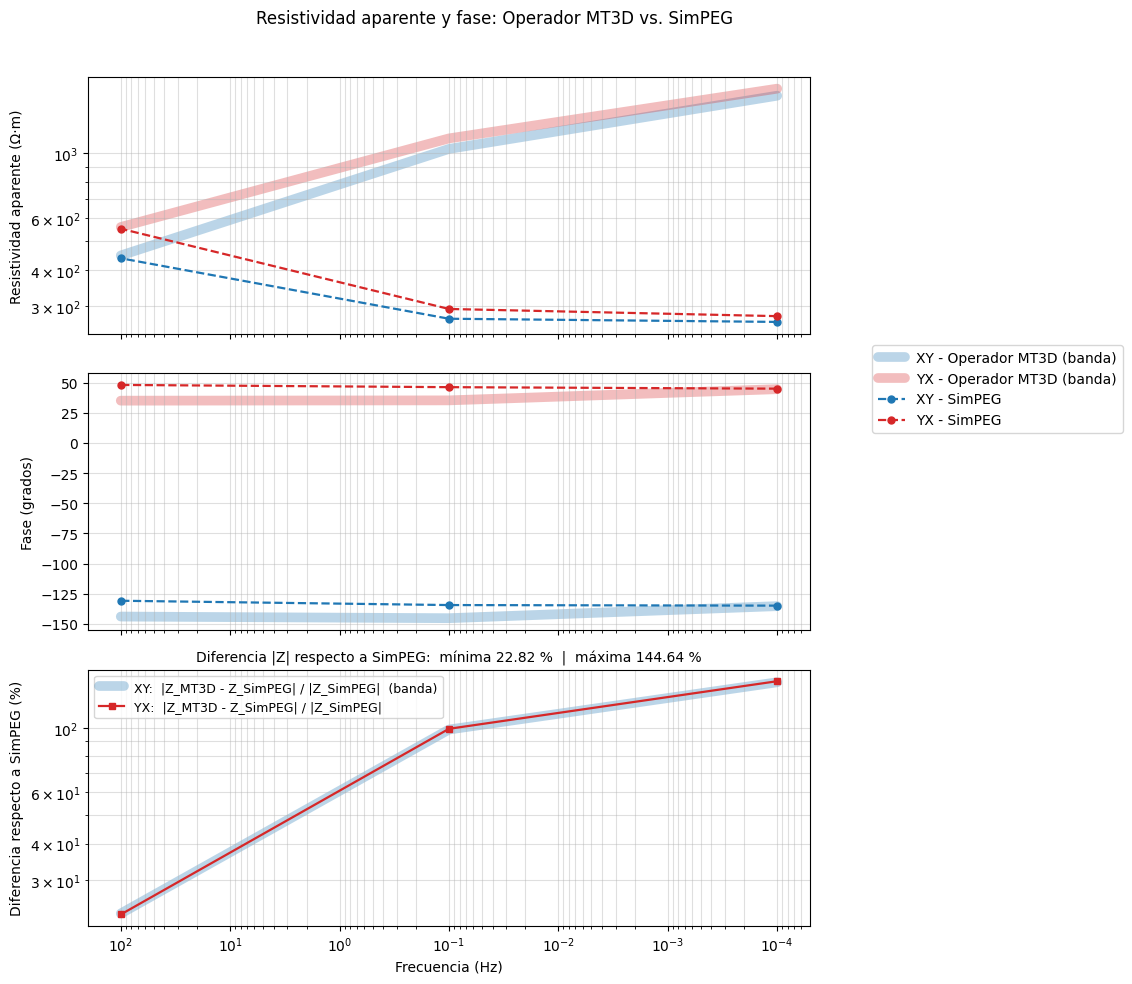

In [13]:
# 7) Resistividad aparente y fase: operador MT3D vs. SimPEG

mu_0 = 4 * np.pi * 1e-7

def apparent_resistivity(Z, frequency):
    omega = 2 * np.pi * np.asarray(frequency)
    return np.abs(Z)**2 / (mu_0 * omega)

def phase_deg(Z):
    return np.degrees(np.angle(Z))

# Receptor a comparar
irec = 0

# Ordenar frecuencias de menor a mayor para conectar las curvas
orden = np.argsort(frequency_list)
frec = frequency_list[orden]

# --- Componentes XY / YX ---
Zxy_op = impedance_op[irec, orden, 0, 1]
Zyx_op = impedance_op[irec, orden, 1, 0]

Zxy_sp = impedance_sp[irec, orden, 0, 1]
Zyx_sp = impedance_sp[irec, orden, 1, 0]

# --- Resistividad aparente ---
rho_xy_op = apparent_resistivity(Zxy_op, frec)
rho_yx_op = apparent_resistivity(Zyx_op, frec)

rho_xy_sp = apparent_resistivity(Zxy_sp, frec)
rho_yx_sp = apparent_resistivity(Zyx_sp, frec)

# --- Fase ---
phi_xy_op = phase_deg(Zxy_op)
phi_yx_op = phase_deg(Zyx_op)

phi_xy_sp = phase_deg(Zxy_sp)
phi_yx_sp = phase_deg(Zyx_sp)

# --- Diferencias respecto a SimPEG ---
dif_Z_xy = np.abs(Zxy_op - Zxy_sp) / np.abs(Zxy_sp) * 100
dif_Z_yx = np.abs(Zyx_op - Zyx_sp) / np.abs(Zyx_sp) * 100

dif_rho_xy = np.abs(rho_xy_op - rho_xy_sp) / np.abs(rho_xy_sp) * 100
dif_rho_yx = np.abs(rho_yx_op - rho_yx_sp) / np.abs(rho_yx_sp) * 100

dif_phi_xy = np.abs(phi_xy_op - phi_xy_sp)
dif_phi_yx = np.abs(phi_yx_op - phi_yx_sp)

# Razon |Z_operador| / |Z_SimPEG| (1.0 = coinciden)
razon_xy = np.abs(Zxy_op) / np.abs(Zxy_sp)
razon_yx = np.abs(Zyx_op) / np.abs(Zyx_sp)

print("=" * 84)
print("OPERADOR MT3D vs. SimPEG  -  IMPEDANCIA")
print("=" * 84)
print(f"{'f [Hz]':>10} | {'|dZxy|/|Zxy| %':>15} {'|dZyx|/|Zyx| %':>15} | "
      f"{'d_rho_xy %':>11} {'d_rho_yx %':>11} | {'d_phi_xy °':>11} {'d_phi_yx °':>11}")
print("-" * 84)
for j, f in enumerate(frec):
    print(f"{f:10.1e} | {dif_Z_xy[j]:15.4f} {dif_Z_yx[j]:15.4f} | "
          f"{dif_rho_xy[j]:11.4f} {dif_rho_yx[j]:11.4f} | {dif_phi_xy[j]:11.4f} {dif_phi_yx[j]:11.4f}")

print()
print("=" * 84)
print("RAZON |Z_MT3D| / |Z_SimPEG|   (1.0 = coinciden)")
print("=" * 84)
print(f"{'f [Hz]':>10} | {'XY':>10} {'YX':>10}")
print("-" * 84)
for j, f in enumerate(frec):
    print(f"{f:10.1e} | {razon_xy[j]:10.4f} {razon_yx[j]:10.4f}")

# El operador pone NaN donde la matriz de campos magneticos queda mal condicionada
print("\nNaN en el operador MT3D -> Zxy:", np.isnan(Zxy_op).sum(), "| Zyx:", np.isnan(Zyx_op).sum())

# ---------------------------------------------------------------
# Plot comparativo
# Operador MT3D: banda gruesa translucida (halo)
# SimPEG: linea fina a guiones encima. Si SimPEG cae dentro de la banda, coinciden.
# ---------------------------------------------------------------
c_xy = "tab:blue"
c_yx = "tab:red"

kw_op = dict(linestyle="-", linewidth=7, alpha=0.30, solid_capstyle="round", zorder=1)
kw_sp = dict(linestyle="--", linewidth=1.6, marker="o", markersize=5, zorder=3)

fig, (ax_rho, ax_phi, ax_dif) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# --- Resistividad aparente
ax_rho.plot(frec, rho_xy_op, color=c_xy, label="XY - Operador MT3D (banda)", **kw_op)
ax_rho.plot(frec, rho_yx_op, color=c_yx, label="YX - Operador MT3D (banda)", **kw_op)
ax_rho.plot(frec, rho_xy_sp, color=c_xy, label="XY - SimPEG", **kw_sp)
ax_rho.plot(frec, rho_yx_sp, color=c_yx, label="YX - SimPEG", **kw_sp)

ax_rho.set_xscale("log")
ax_rho.set_yscale("log")
ax_rho.set_ylabel("Resistividad aparente (Ω·m)")
ax_rho.grid(True, which="both", alpha=0.4)

# --- Fase
ax_phi.plot(frec, phi_xy_op, color=c_xy, **kw_op)
ax_phi.plot(frec, phi_yx_op, color=c_yx, **kw_op)
ax_phi.plot(frec, phi_xy_sp, color=c_xy, **kw_sp)
ax_phi.plot(frec, phi_yx_sp, color=c_yx, **kw_sp)

ax_phi.set_xscale("log")
ax_phi.set_ylabel("Fase (grados)")
ax_phi.grid(True, which="both", alpha=0.4)

# --- Diferencia respecto a SimPEG
ax_dif.plot(
    frec, dif_Z_xy,
    color=c_xy, linestyle="-", linewidth=7, alpha=0.30,
    solid_capstyle="round", zorder=1,
    label="XY:  |Z_MT3D - Z_SimPEG| / |Z_SimPEG|  (banda)"
)
ax_dif.plot(
    frec, dif_Z_yx,
    color=c_yx, linestyle="-", marker="s", markersize=5, linewidth=1.6, zorder=3,
    label="YX:  |Z_MT3D - Z_SimPEG| / |Z_SimPEG|"
)

ax_dif.set_xscale("log")
ax_dif.set_yscale("log")
ax_dif.set_xlabel("Frecuencia (Hz)")
ax_dif.set_ylabel("Diferencia respecto a SimPEG (%)")
ax_dif.grid(True, which="both", alpha=0.4)
ax_dif.legend(loc="upper left", fontsize=9)

dif_max = max(np.nanmax(dif_Z_xy), np.nanmax(dif_Z_yx))
dif_min = min(np.nanmin(dif_Z_xy), np.nanmin(dif_Z_yx))
ax_dif.set_title(
    f"Diferencia |Z| respecto a SimPEG:  mínima {dif_min:.2f} %  |  máxima {dif_max:.2f} %",
    fontsize=10
)

for ax in (ax_rho, ax_phi, ax_dif):
    ax.invert_xaxis()

handles, labels = ax_rho.get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.87, 0.6))

fig.suptitle("Resistividad aparente y fase: Operador MT3D vs. SimPEG")

plt.tight_layout(rect=[0, 0, 0.83, 0.96])
plt.savefig("Resistividad_Fase_MT3D-SimPEG.png", dpi=300, bbox_inches="tight")
plt.show()


OPERADOR MT3D vs. SimPEG  -  TIPPER
    f [Hz] |   |dTzx|/|Tzx| %   |dTzy|/|Tzy| % |   |Tzx| MT3D  |Tzx| SimPEG
--------------------------------------------------------------------------------
   1.0e-04 |          14.3162         117.4577 |     0.000023      0.000021
   1.0e-01 |          12.0072          78.3759 |     0.011720      0.013158
   1.0e+02 |          22.8075          24.4133 |     0.096643      0.113504

NaN en el operador MT3D -> Tzx: 0 | Tzy: 0


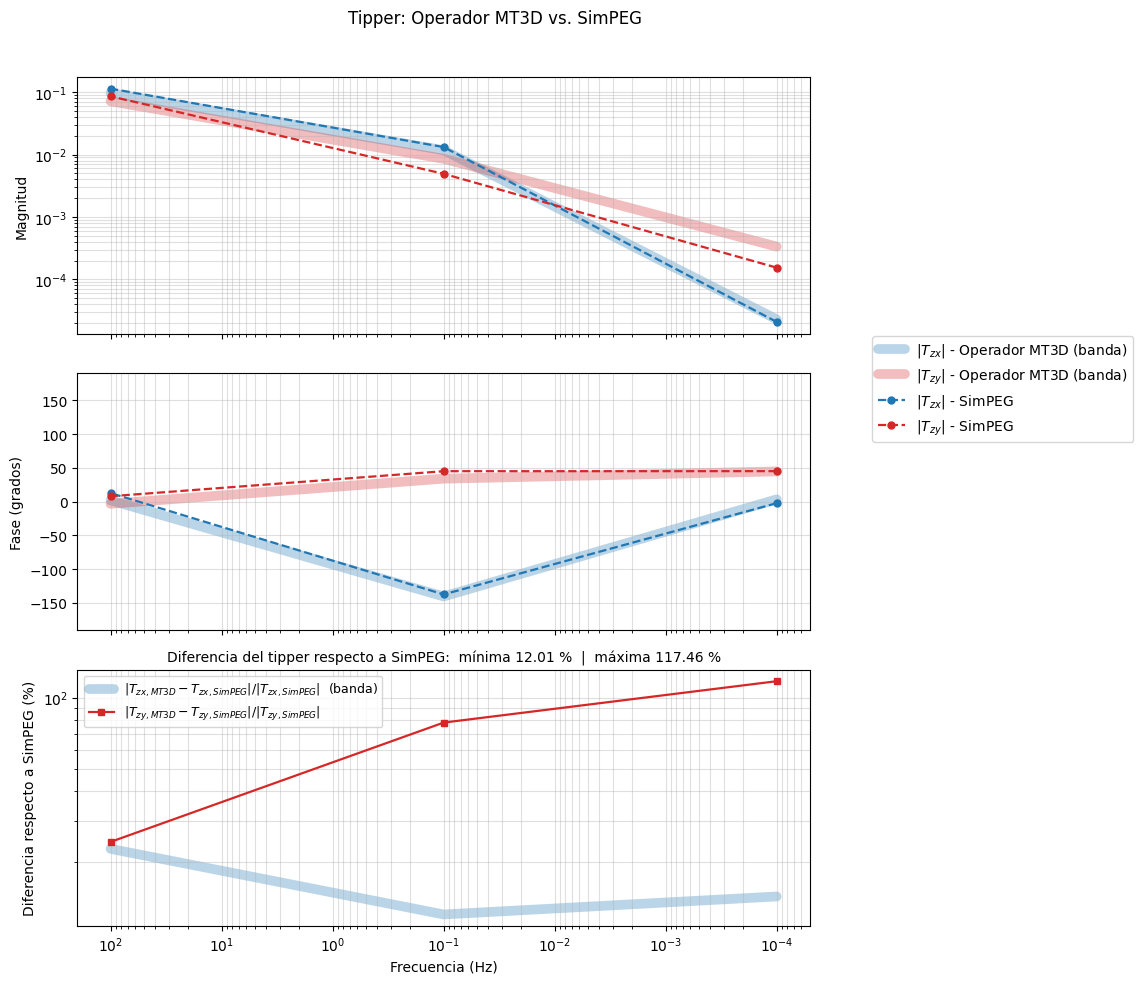

In [14]:
# 8) Tipper: operador MT3D vs. SimPEG

irec = 0
orden = np.argsort(frequency_list)
frec = frequency_list[orden]

# --- Componentes Tzx / Tzy ---
Tzx_op = tipper_op[irec, orden, 0]
Tzy_op = tipper_op[irec, orden, 1]

Tzx_sp = tipper_sp[irec, orden, 0]
Tzy_sp = tipper_sp[irec, orden, 1]

# --- Magnitud y fase ---
mag_tzx_op = np.abs(Tzx_op)
mag_tzy_op = np.abs(Tzy_op)

mag_tzx_sp = np.abs(Tzx_sp)
mag_tzy_sp = np.abs(Tzy_sp)

phi_tzx_op = np.degrees(np.angle(Tzx_op))
phi_tzy_op = np.degrees(np.angle(Tzy_op))

phi_tzx_sp = np.degrees(np.angle(Tzx_sp))
phi_tzy_sp = np.degrees(np.angle(Tzy_sp))

# --- Diferencias respecto a SimPEG ---
dif_T_zx = np.abs(Tzx_op - Tzx_sp) / np.abs(Tzx_sp) * 100
dif_T_zy = np.abs(Tzy_op - Tzy_sp) / np.abs(Tzy_sp) * 100

print("=" * 80)
print("OPERADOR MT3D vs. SimPEG  -  TIPPER")
print("=" * 80)
print(f"{'f [Hz]':>10} | {'|dTzx|/|Tzx| %':>16} {'|dTzy|/|Tzy| %':>16} | "
      f"{'|Tzx| MT3D':>12} {'|Tzx| SimPEG':>13}")
print("-" * 80)
for j, f in enumerate(frec):
    print(f"{f:10.1e} | {dif_T_zx[j]:16.4f} {dif_T_zy[j]:16.4f} | "
          f"{mag_tzx_op[j]:12.6f} {mag_tzx_sp[j]:13.6f}")

print("\nNaN en el operador MT3D -> Tzx:", np.isnan(Tzx_op).sum(), "| Tzy:", np.isnan(Tzy_op).sum())

# ---------------------------------------------------------------
# Plot comparativo del tipper
# Operador MT3D = banda gruesa translucida, SimPEG = guiones encima
# ---------------------------------------------------------------
c_tzx = "tab:blue"
c_tzy = "tab:red"

kw_op = dict(linestyle="-", linewidth=7, alpha=0.30, solid_capstyle="round", zorder=1)
kw_sp = dict(linestyle="--", linewidth=1.6, marker="o", markersize=5, zorder=3)

fig, (ax_mag, ax_phi, ax_dif) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# --- Magnitud
ax_mag.plot(frec, mag_tzx_op, color=c_tzx, label=r"$|T_{zx}|$ - Operador MT3D (banda)", **kw_op)
ax_mag.plot(frec, mag_tzy_op, color=c_tzy, label=r"$|T_{zy}|$ - Operador MT3D (banda)", **kw_op)
ax_mag.plot(frec, mag_tzx_sp, color=c_tzx, label=r"$|T_{zx}|$ - SimPEG", **kw_sp)
ax_mag.plot(frec, mag_tzy_sp, color=c_tzy, label=r"$|T_{zy}|$ - SimPEG", **kw_sp)

ax_mag.set_xscale("log")
ax_mag.set_yscale("log")
ax_mag.set_ylabel("Magnitud")
ax_mag.grid(True, which="both", alpha=0.4)

# --- Fase
ax_phi.plot(frec, phi_tzx_op, color=c_tzx, **kw_op)
ax_phi.plot(frec, phi_tzy_op, color=c_tzy, **kw_op)
ax_phi.plot(frec, phi_tzx_sp, color=c_tzx, **kw_sp)
ax_phi.plot(frec, phi_tzy_sp, color=c_tzy, **kw_sp)

ax_phi.set_xscale("log")
ax_phi.set_ylabel("Fase (grados)")
ax_phi.set_ylim(-190, 190)
ax_phi.grid(True, which="both", alpha=0.4)

# --- Diferencia respecto a SimPEG
ax_dif.plot(
    frec, dif_T_zx,
    color=c_tzx, linestyle="-", linewidth=7, alpha=0.30,
    solid_capstyle="round", zorder=1,
    label=r"$|T_{zx,MT3D} - T_{zx,SimPEG}| / |T_{zx,SimPEG}|$  (banda)"
)
ax_dif.plot(
    frec, dif_T_zy,
    color=c_tzy, linestyle="-", marker="s", markersize=5, linewidth=1.6, zorder=3,
    label=r"$|T_{zy,MT3D} - T_{zy,SimPEG}| / |T_{zy,SimPEG}|$"
)

ax_dif.set_xscale("log")
ax_dif.set_yscale("log")
ax_dif.set_xlabel("Frecuencia (Hz)")
ax_dif.set_ylabel("Diferencia respecto a SimPEG (%)")
ax_dif.grid(True, which="both", alpha=0.4)
ax_dif.legend(loc="upper left", fontsize=9)

dif_max_T = max(np.nanmax(dif_T_zx), np.nanmax(dif_T_zy))
dif_min_T = min(np.nanmin(dif_T_zx), np.nanmin(dif_T_zy))
ax_dif.set_title(
    f"Diferencia del tipper respecto a SimPEG:  mínima {dif_min_T:.2f} %  |  máxima {dif_max_T:.2f} %",
    fontsize=10
)

for ax in (ax_mag, ax_phi, ax_dif):
    ax.invert_xaxis()

handles, labels = ax_mag.get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.87, 0.6))

fig.suptitle("Tipper: Operador MT3D vs. SimPEG")

plt.tight_layout(rect=[0, 0, 0.83, 0.96])
plt.savefig("Tipper_MT3D-SimPEG.png", dpi=300, bbox_inches="tight")
plt.show()


In [15]:
# 9) Métricas de error del operador MT3D respecto a SimPEG

def metricas_error(operador, simpeg, nombre="Variable", unidad="Ω·m"):
    operador = np.asarray(operador, dtype=float)
    simpeg = np.asarray(simpeg, dtype=float)

    # Eliminar NaN, inf y evitar divisiones por cero en MAPE
    mask = (
        np.isfinite(operador)
        & np.isfinite(simpeg)
        & (np.abs(simpeg) > 1e-12)
    )

    n_desc = operador.size - mask.sum()

    operador = operador[mask]
    simpeg = simpeg[mask]

    error = operador - simpeg

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error**2))
    mape = np.mean(np.abs(error / simpeg)) * 100

    print(f"\n{nombre}   (n={mask.sum()}, descartados={n_desc})")
    print(f"MAE  = {mae:.4f} {unidad}")
    print(f"RMSE = {rmse:.4f} {unidad}")
    print(f"MAPE = {mape:.2f} %")

    return mae, rmse, mape


print("=" * 60)
print("RESISTIVIDAD APARENTE: MT3D vs. SimPEG")
print("=" * 60)
metricas_error(rho_xy_op, rho_xy_sp, nombre="Resistividad aparente XY")
metricas_error(rho_yx_op, rho_yx_sp, nombre="Resistividad aparente YX")

print("\n" + "=" * 60)
print("FASE: MT3D vs. SimPEG")
print("=" * 60)
metricas_error(phi_xy_op, phi_xy_sp, nombre="Fase XY", unidad="grados")
metricas_error(phi_yx_op, phi_yx_sp, nombre="Fase YX", unidad="grados")

print("\n" + "=" * 60)
print("TIPPER (magnitud): MT3D vs. SimPEG")
print("=" * 60)
metricas_error(mag_tzx_op, mag_tzx_sp, nombre="|Tzx|", unidad="")
metricas_error(mag_tzy_op, mag_tzy_sp, nombre="|Tzy|", unidad="")


RESISTIVIDAD APARENTE: MT3D vs. SimPEG

Resistividad aparente XY   (n=3, descartados=0)
MAE  = 693.4369 Ω·m
RMSE = 874.0853 Ω·m
MAPE = 258.34 %

Resistividad aparente YX   (n=3, descartados=0)
MAE  = 740.9210 Ω·m
RMSE = 932.2829 Ω·m
MAPE = 260.77 %

FASE: MT3D vs. SimPEG

Fase XY   (n=3, descartados=0)
MAE  = 8.1408 grados
RMSE = 9.8463 grados
MAPE = 6.14 %

Fase YX   (n=3, descartados=0)
MAE  = 8.1430 grados
RMSE = 9.8429 grados
MAPE = 17.23 %

TIPPER (magnitud): MT3D vs. SimPEG

|Tzx|   (n=3, descartados=0)
MAE  = 0.0061 
RMSE = 0.0098 
MAPE = 11.90 %

|Tzy|   (n=3, descartados=0)
MAE  = 0.0060 
RMSE = 0.0085 
MAPE = 69.42 %


(0.0060348223808182645, 0.008512162260408868, 69.42429039625107)

## Cómo leer la comparación

- Las curvas del **operador MT3D** se dibujan como banda gruesa translúcida y las de **SimPEG**
  como línea a guiones encima: donde SimPEG cae dentro de la banda, las dos soluciones coinciden.
- El tercer panel de cada figura es la **diferencia relativa respecto a SimPEG**, en escala
  logarítmica.
- La diferencia crece hacia las **frecuencias bajas**: a $10^{-4}$ Hz el skin depth supera con
  holgura el tamaño del dominio de la malla `mesh_Toy6_MT.json`, así que la respuesta queda
  dominada por los bordes. Es un límite de la **malla**, no una discrepancia de formulación: para
  comparar a esas frecuencias hay que agrandar el dominio y el padding.
- Las diferencias en el **tipper** se leen igual, pero conviene mirar además la magnitud absoluta:
  cuando $|T|$ es muy pequeño, un error relativo grande sigue siendo un error absoluto diminuto.

### Archivos generados por este cuaderno

- `impedance_SimPEG_Toy6.npy`, `tipper_SimPEG_Toy6.npy` — respuesta de SimPEG
- `Resistividad_Fase_MT3D-SimPEG.png` — comparación de resistividad aparente y fase
- `Tipper_MT3D-SimPEG.png` — comparación del tipper
- `Tipper_ModelingToy6_SimPEG.png`, `Modelo_3D_conductividad.png` — figuras de apoyo